In [24]:
# Load the libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

In [25]:
# Load the source CSV from FLOWGUARD_CSV or this project's notebooks folder
current = Path.cwd()
project = current.parent if current.name == "notebooks" else current
if not (project / "notebooks").is_dir():
    raise FileNotFoundError("Run this notebook from the project or notebooks folder")
default_csv = project / "notebooks" / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
csv_path = Path(os.environ.get("FLOWGUARD_CSV", default_csv)).expanduser()
if not csv_path.is_file():
    raise FileNotFoundError(f"Source CSV not found: {csv_path}")
df = pd.read_csv(csv_path, low_memory=False)
df.columns = df.columns.str.strip()
print("Loaded:", csv_path.resolve(), "Rows:", len(df))

Loaded: C:\Users\joy\Desktop\Test2\Flowguard\notebooks\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv Rows: 225745


In [26]:
# Load the CSV
data = df.copy()
original_rows = len(data)
print("Rows:", original_rows, "Columns:", len(data.columns))
display(data.head())

Rows: 225745 Columns: 85


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [27]:
print("Label distribution:")
print(data["Label"].value_counts().to_dict())

print("\nUnique labels:")
print(df["Label"].unique())

Label distribution:
{'DDoS': 128027, 'BENIGN': 97718}

Unique labels:
<StringArray>
['BENIGN', 'DDoS']
Length: 2, dtype: str


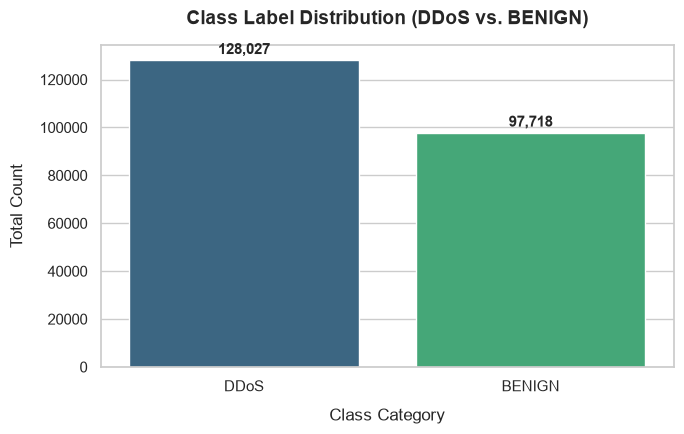

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))

label_counts = data["Label"].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)

plt.title("Class Label Distribution (DDoS vs. BENIGN)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Class Category", fontsize=12, labelpad=10)
plt.ylabel("Total Count", fontsize=12, labelpad=10)


for i, count in enumerate(label_counts.values):
    plt.text(i, count + (max(label_counts.values) * 0.01), f"{count:,}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
print("Column names:", data.columns.tolist())
print("")

print("Missing values:", int(data.isna().sum().sum()))
print("Infinite values:", int(np.isinf(data.select_dtypes(include=np.number)).sum().sum()))
print("Duplicate rows:", int(data.duplicated().sum()))

Column names: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

In [30]:
#Removes Unnecessary Spaces
data.columns = data.columns.str.strip()
data["Label"] = data["Label"].astype(str).str.strip()
data = data.replace([np.inf, -np.inf], np.nan)
print("Labels:", data["Label"].value_counts().to_dict())

Labels: {'DDoS': 128027, 'BENIGN': 97718}


In [31]:
# Keep BENIGN and DDoS; remove duplicate rows
data = data.loc[data["Label"].isin(["BENIGN", "DDoS"])]
data = data.drop_duplicates().reset_index(drop=True)
print("Before:", original_rows, "After:", len(data))

Before: 225745 After: 225743


In [32]:
# Exclude labels, identifiers, ports, time, and possible capture fingerprints
excluded = [
    "Label", "Flow ID", "Source IP", "Destination IP",
    "Source Port", "Destination Port", "Timestamp",
    "Init_Win_bytes_forward", "Init_Win_bytes_backward",
    "Avg Bwd Segment Size",
    "Bwd Packet Length Max",
    "Bwd Packet Length Std",
    "Fwd Packet Length Std",
    "Flow IAT Std",
    "Fwd IAT Max",
    "Fwd Header Length",
    "Fwd Header Length.1",
]
model_data = data.drop(columns=excluded)
print("Remaining columns:", len(model_data.columns))

Remaining columns: 68


In [33]:
# Keep numerical flow measurements
model_data = model_data.select_dtypes(include=np.number)
print("Numerical columns:", len(model_data.columns))
print("Missing values after cleaning:", int(model_data.isna().sum().sum()))

Numerical columns: 68
Missing values after cleaning: 68


In [34]:
# Encode BENIGN and DDoS
labels = data["Label"].map({"BENIGN": 0, "DDoS": 1})
print("BENIGN = 0, DDoS = 1")
print("Class counts:", labels.value_counts().to_dict())

BENIGN = 0, DDoS = 1
Class counts: {1: 128027, 0: 97716}


In [35]:
# Group nearby traffic by time
time_blocks = pd.to_datetime(
    data["Timestamp"], format="%m/%d/%Y %H:%M", errors="raise"
).dt.floor("2min")
print("Two-minute groups:", time_blocks.nunique())

Two-minute groups: 47


In [36]:
# Hold out test groups
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
trainval_rows, test_rows = next(
    outer.split(model_data, labels, groups=time_blocks)
)
assert set(time_blocks.iloc[trainval_rows]).isdisjoint(set(time_blocks.iloc[test_rows]))
print("Development rows:", len(trainval_rows))
print("Test rows:", len(test_rows))

Development rows: 180176
Test rows: 45567


In [37]:
# Keep all numeric columns until the training split is known
feature_names = model_data.columns.tolist()
print("Numeric candidate columns:", len(feature_names))

Numeric candidate columns: 68


In [38]:
# Prepare the development and test tables
X = model_data[feature_names]
X_trainval, X_test = X.iloc[trainval_rows], X.iloc[test_rows]
y_trainval, y_test = labels.iloc[trainval_rows], labels.iloc[test_rows]
trainval_groups = time_blocks.iloc[trainval_rows]
print("Development shape:", X_trainval.shape)
print("Testing shape:", X_test.shape)

Development shape: (180176, 68)
Testing shape: (45567, 68)


In [39]:
# Split training and validation groups before selecting features
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=24)
train_rows, val_rows = next(
    inner.split(X_trainval, y_trainval, groups=trainval_groups)
)
X_train, X_val = X_trainval.iloc[train_rows], X_trainval.iloc[val_rows]
y_train, y_val = y_trainval.iloc[train_rows], y_trainval.iloc[val_rows]
train_groups = trainval_groups.iloc[train_rows]
assert set(train_groups).isdisjoint(set(trainval_groups.iloc[val_rows]))

# Remove constant and exactly repeated columns using training rows only.
constant_columns = [
    name for name in X_train
    if X_train[name].nunique(dropna=True) <= 1
]
candidate_names = []
duplicate_columns = []
for name in X_train.columns:
    if name in constant_columns:
        continue
    matching = next(
        (kept for kept in candidate_names if X_train[name].equals(X_train[kept])),
        None,
    )
    if matching is None:
        candidate_names.append(name)
    else:
        duplicate_columns.append((name, matching))

assert len(candidate_names) >= 10
X = X[candidate_names]
X_trainval = X_trainval[candidate_names]
X_test = X_test[candidate_names]
X_train = X_train[candidate_names]
X_val = X_val[candidate_names]
feature_names = candidate_names
print("Removed constant columns:", constant_columns)
print("Removed exact duplicates:", duplicate_columns)
print("Candidate features for fold-safe top-20 selection:", len(feature_names))
for name, values in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(name, len(values), values.value_counts().to_dict())
    assert values.nunique() == 2

Removed constant columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Removed exact duplicates: [('SYN Flag Count', 'Fwd PSH Flags'), ('ECE Flag Count', 'RST Flag Count'), ('Avg Fwd Segment Size', 'Fwd Packet Length Mean'), ('Subflow Fwd Packets', 'Total Fwd Packets'), ('Subflow Fwd Bytes', 'Total Length of Fwd Packets'), ('Subflow Bwd Packets', 'Total Backward Packets'), ('Subflow Bwd Bytes', 'Total Length of Bwd Packets')]
Candidate features for fold-safe top-20 selection: 51
Train 139968 {1: 77013, 0: 62955}
Validation 40208 {1: 24647, 0: 15561}
Test 45567 {1: 26367, 0: 19200}


In [40]:
# Remove constant and exactly repeated columns using training rows only.
constant_columns = [
    name for name in X_train
    if X_train[name].nunique(dropna=True) <= 1
]
candidate_names = []
duplicate_columns = []
for name in X_train.columns:
    if name in constant_columns:
        continue
    matching = next(
        (kept for kept in candidate_names if X_train[name].equals(X_train[kept])),
        None,
    )
    if matching is None:
        candidate_names.append(name)
    else:
        duplicate_columns.append((name, matching))

X = X[candidate_names]
X_trainval = X_trainval[candidate_names]
X_test = X_test[candidate_names]
X_train = X_train[candidate_names]
X_val = X_val[candidate_names]

In [41]:
# Save the fixed 10-feature set; no model-based feature selector is used
FEATURE_NAMES = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Min",
    "Fwd IAT Total",
    "Fwd IAT Std",
    "act_data_pkt_fwd",
    "Bwd Header Length",
]
missing = [name for name in FEATURE_NAMES if name not in X.columns]
if missing:
    raise ValueError(f"Fixed features missing after preprocessing: {missing}")

split = np.full(len(data), "test", dtype=object)
split[trainval_rows] = "validation"
split[trainval_rows[train_rows]] = "train"
prepared = X[FEATURE_NAMES].copy()
prepared["Label"] = labels.astype(int)
prepared["time_group"] = time_blocks.dt.strftime("%Y-%m-%d %H:%M:%S")
prepared["split"] = split
prepared_path = project / "notebooks" / "prepared_network_traffic.csv"
prepared.to_csv(prepared_path, index=False)
assert prepared["split"].value_counts().to_dict() == {
    "train": len(train_rows), "validation": len(val_rows), "test": len(test_rows)
}
print("Saved:", prepared_path.resolve(), "Rows:", len(prepared))
print("Fixed model features:", FEATURE_NAMES)

Saved: C:\Users\joy\Desktop\Test2\Flowguard\notebooks\prepared_network_traffic.csv Rows: 225743
Fixed model features: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Fwd IAT Total', 'Fwd IAT Std', 'act_data_pkt_fwd', 'Bwd Header Length']


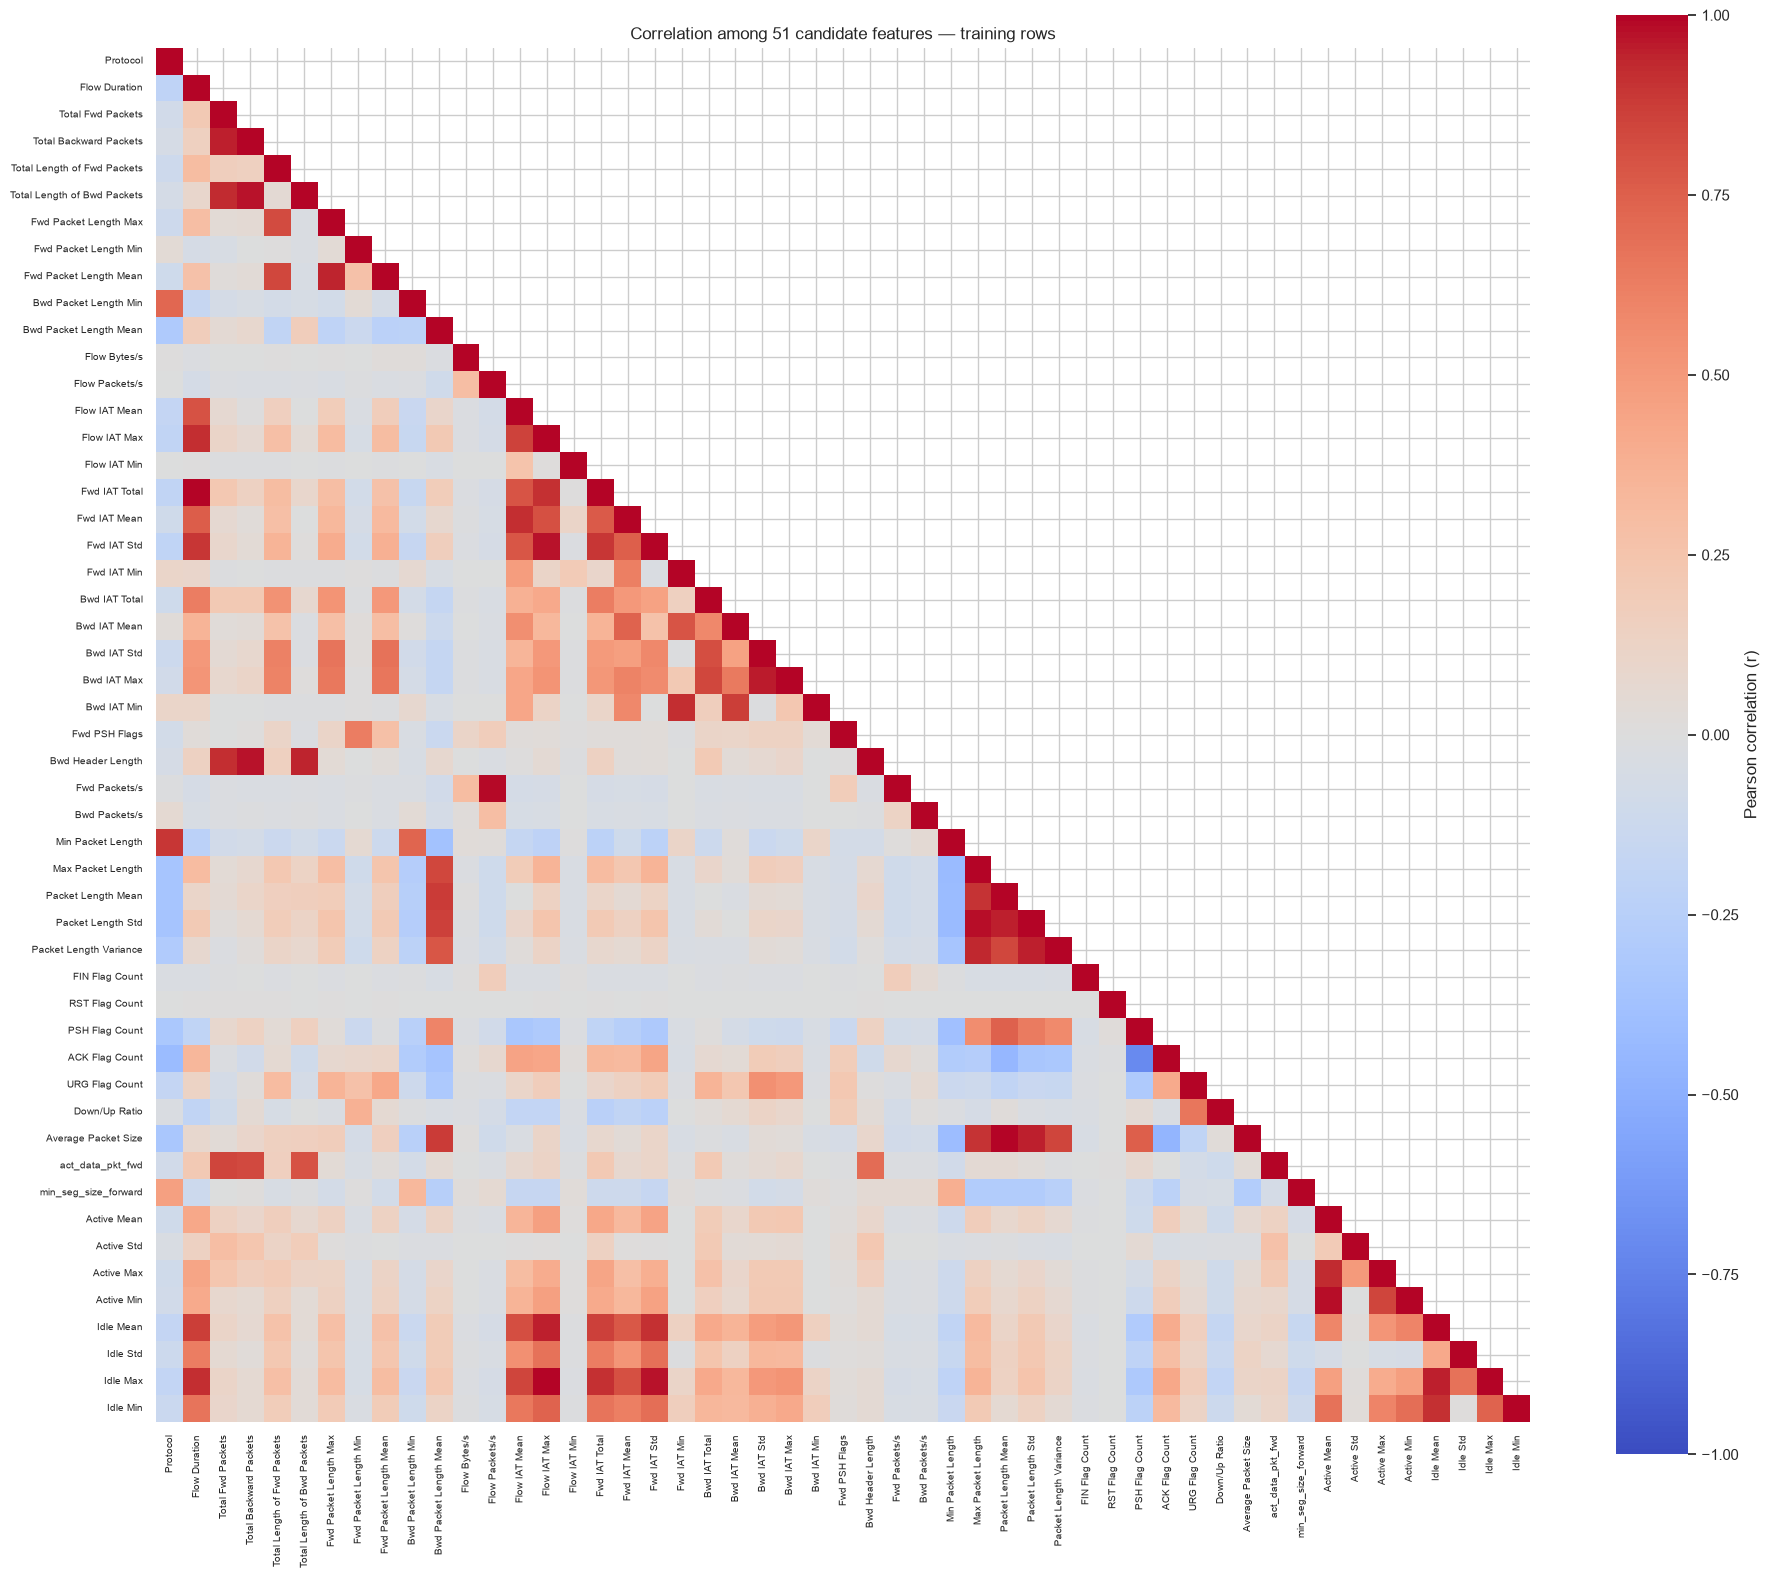

,Feature 1,Feature 2,Pearson r,Absolute r
1621,Packet Length Mean,Average Packet Size,0.999,0.999
763,Flow IAT Max,Idle Max,0.998,0.998
67,Flow Duration,Fwd IAT Total,0.997,0.997
639,Flow Packets/s,Fwd Packets/s,0.985,0.985
1562,Max Packet Length,Packet Length Std,0.984,0.984
2239,Active Mean,Active Min,0.978,0.978
179,Total Backward Packets,Bwd Header Length,0.973,0.973
732,Flow IAT Max,Fwd IAT Std,0.972,0.972
967,Fwd IAT Std,Idle Max,0.970,0.970
158,Total Backward Packets,Total Length of Bwd Packets,0.969,0.969


In [42]:
# Correlations among the 51 candidates, using training rows only
corr_51 = X_train.corr(method="pearson")
upper_mask = np.triu(np.ones(corr_51.shape, dtype=bool), k=1)

plt.figure(figsize=(19, 16))
sns.heatmap(
    corr_51,
    mask=upper_mask,
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Pearson correlation (r)"},
)
plt.title("Correlation among 51 candidate features — training rows")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# A readable table of the strongest pairs
pairs = corr_51.where(upper_mask).stack().reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Pearson r"]
pairs["Absolute r"] = pairs["Pearson r"].abs()
display(
    pairs.loc[pairs["Absolute r"] >= 0.90]
    .sort_values("Absolute r", ascending=False)
    .round(3)
)

,Rank,Feature,Importance,Selected for website
0,1,Fwd Packet Length Max,0.144495,True
1,2,Fwd Packet Length Mean,0.116408,True
2,3,act_data_pkt_fwd,0.094382,True
3,4,Total Length of Fwd Packets,0.065529,True
4,5,Fwd IAT Std,0.062598,True
5,6,Fwd IAT Total,0.053769,True
6,7,Bwd Packet Length Mean,0.049032,False
7,8,Total Backward Packets,0.047446,True
8,9,Bwd Packet Length Min,0.046455,True
9,10,Average Packet Size,0.045999,False


,Rank,Feature,Importance,Selected for website
0,1,Fwd Packet Length Max,0.144495,True
1,2,Fwd Packet Length Mean,0.116408,True
2,3,act_data_pkt_fwd,0.094382,True
3,4,Total Length of Fwd Packets,0.065529,True
4,5,Fwd IAT Std,0.062598,True
5,6,Fwd IAT Total,0.053769,True
7,8,Total Backward Packets,0.047446,True
8,9,Bwd Packet Length Min,0.046455,True
10,11,Total Fwd Packets,0.042709,True
12,13,Bwd Header Length,0.031646,True


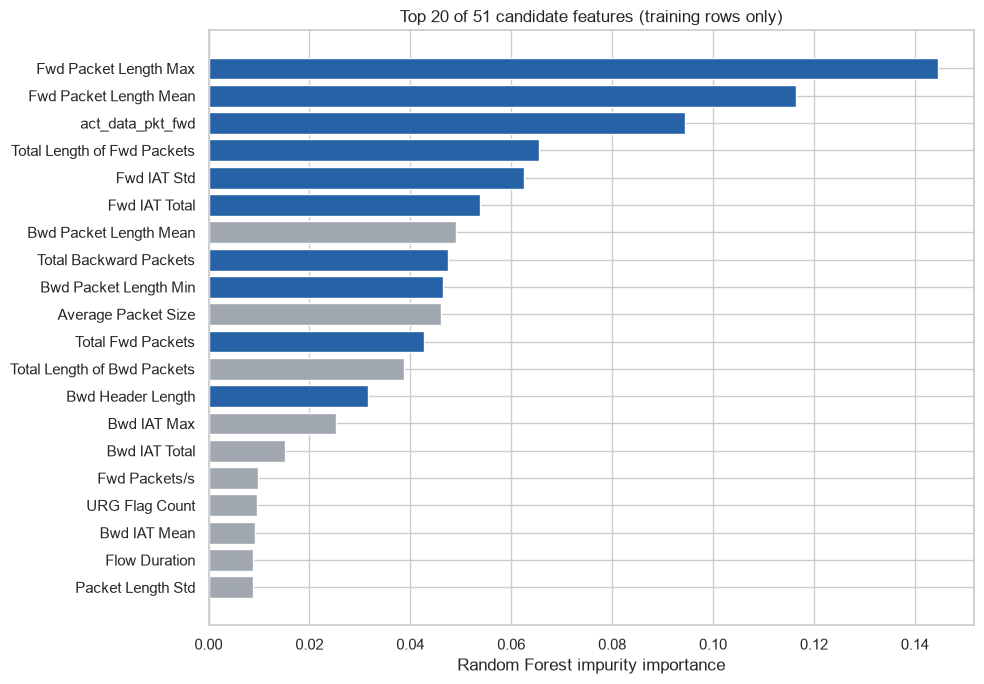

In [43]:
# Diagnostic only: rank all 51 candidate features using training rows.
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

audit_X = SimpleImputer(strategy="median").fit_transform(X_train)
audit_forest = RandomForestClassifier(
    n_estimators=50, max_depth=12, random_state=42, n_jobs=2
)
audit_forest.fit(audit_X, y_train)

ranks = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": audit_forest.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

ranks.insert(0, "Rank", ranks.index + 1)
ranks["Selected for website"] = ranks["Feature"].isin(FEATURE_NAMES)

display(ranks.head(20))
display(ranks.loc[ranks["Selected for website"]])

top = ranks.head(20).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(
    top["Feature"], top["Importance"],
    color=np.where(top["Selected for website"], "#2563a6", "#a0a7b0"),
)
plt.xlabel("Random Forest impurity importance")
plt.title("Top 20 of 51 candidate features (training rows only)")
plt.tight_layout()
plt.show()

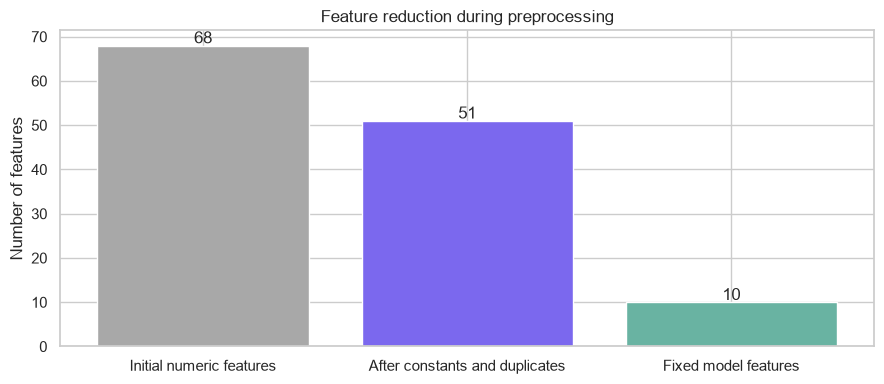

In [45]:
names = ["Initial numeric features", "After constants and duplicates", "Fixed model features"]
values = [len(model_data.columns), len(candidate_names), len(FEATURE_NAMES)]

plt.figure(figsize=(9, 4))
plt.bar(names, values, color=["#a8a8a8", "#7b68ee", "#69b3a2"])
plt.ylabel("Number of features")
plt.title("Feature reduction during preprocessing")
for i, value in enumerate(values):
    plt.text(i, value + 0.5, str(value), ha="center")
plt.tight_layout()
plt.show()